In [22]:
import pandas as pd
import numpy as np 

INPUT = pd.read_csv("./Input_JT_BCS.csv")
OUTPUT = pd.read_excel("./Saidas.xlsx")

INPUT = INPUT.ffill()
OUTPUT = OUTPUT.ffill()

display(INPUT)
display(OUTPUT)

PREDICTORS = ["f", "Zc"]
TARGETS = ["Y1", "Y2"]

,f,Zc
0,12.420959,6.638400
1,12.420959,6.638400
2,12.420959,6.638400
3,12.420959,6.638400
4,12.420959,6.638400
...,...,...
495,11.684187,10.177428
496,11.684187,10.177428
497,11.684187,10.177428
498,11.684187,10.177428


,Y1,Y2
0,2.306457,44.101956
1,2.504378,43.516537
2,2.653644,43.227625
3,2.767146,43.076602
4,2.853953,42.994524
...,...,...
495,2.786123,44.703215
496,2.786124,44.703215
497,2.786124,44.703215
498,2.786125,44.703215


In [23]:
# Selecionar apenas colunas desejadas
inputs = INPUT[PREDICTORS].reset_index(drop=True)
outputs = OUTPUT[TARGETS].reset_index(drop=True)

# Concatenar ignorando índices
data = pd.concat([inputs, outputs], axis=1)

display(data)

,f,Zc,Y1,Y2
0,12.420959,6.638400,2.306457,44.101956
1,12.420959,6.638400,2.504378,43.516537
2,12.420959,6.638400,2.653644,43.227625
3,12.420959,6.638400,2.767146,43.076602
4,12.420959,6.638400,2.853953,42.994524
...,...,...,...,...
495,11.684187,10.177428,2.786123,44.703215
496,11.684187,10.177428,2.786124,44.703215
497,11.684187,10.177428,2.786124,44.703215
498,11.684187,10.177428,2.786125,44.703215


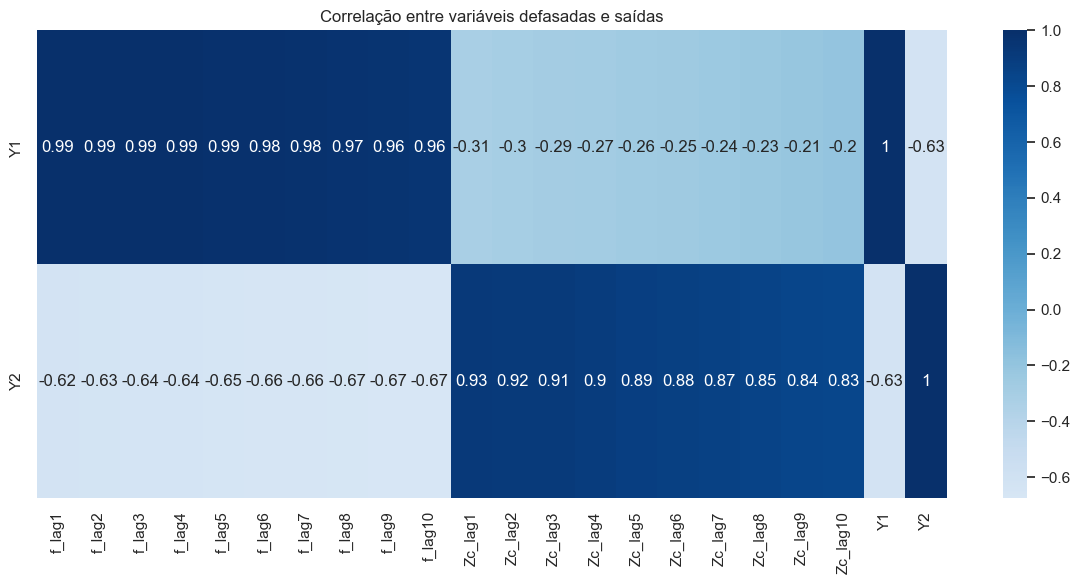

In [24]:
# ==============================
# Análise de Lags
# ==============================

n_lags = 10

lagged_data = pd.DataFrame()

for col in PREDICTORS:
    for lag in range(1, n_lags + 1):
        lagged_data[f"{col}_lag{lag}"] = data[col].shift(lag)

# adicionar targets
for t in TARGETS:
    lagged_data[t] = data[t]

# remover NaN
lagged_data = lagged_data.dropna()


# ==============================
# Correlação
# ==============================

corr = lagged_data.corr()

plt.figure(figsize=(12,6))

sns.heatmap(
    corr[TARGETS].T,
    annot=True,
    cmap="Blues",
    center=0
)

plt.title("Correlação entre variáveis defasadas e saídas")

plt.tight_layout()

plt.show()

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# Scale our data to have mean 0
scaler = StandardScaler()
data[PREDICTORS] = scaler.fit_transform(data[PREDICTORS])

# Split into train (70%), validation (15%), and test (15%) sets
train_data, temp_data = train_test_split(data, test_size=0.3, shuffle=False)
valid_data, test_data = train_test_split(temp_data, test_size=0.5, shuffle=False)

# Convertendo para arrays numpy
train_x = train_data[PREDICTORS].to_numpy()
train_y = train_data[TARGETS].to_numpy()

x_val = valid_data[PREDICTORS].to_numpy()
y_val = valid_data[TARGETS].to_numpy()

x_test = test_data[PREDICTORS].to_numpy()
y_test = test_data[TARGETS].to_numpy()


Above, we initialized our network parameters. We used the numpy random.rand function to randomly create parameter matrices of a certain shape. This network will take in a single input feature, turn it into 2 hidden features, and output one prediction.

In [26]:
def mse_grad(y, y_pred):
    return (y_pred - y)

In [27]:
class Layers():
    def __init__(self, lr, time_steps, i, h, o):
        self.time_steps = time_steps
        self.learning_rate = lr
        
        self.i = i
        self.h = h
        self.o = o
        
    def InitWeights(self, i, h, o, k):
        self.U = np.random.rand(i, h) * (2 * k) - k # Input weights connection
        self.W = np.random.rand(h, h) * (2 * k) - k # Hidden to hidden weight connections
        self.b = np.random.rand(1, h) * (2 * k) - k # Hidden bias

        # Tanh pushes values to between -1 and 1, so scale up the output weights
        self.V = np.random.rand(h, o) * (2 * k) - k # Output weight connections - (n x 1)
        self.c = np.random.rand(1, o) * (2 * k) - k # Output bias
        
    def ForwardPass(self, xt, prevH):
        at = self.b + (xt @ self.U) + (prevH @ self.W) # = (xt @ self.U) = (1 x 1)
        ht = np.tanh(at)  # (1 x 1)
        ot = self.c + (ht @ self.V) # (1 x 1)
        return (ht, ot)
    
    
    def UpdateParameters(self, V_grad, c_grad, W_grad, b_grad, U_grad ):
        # We'll divide the learning rate by the sequence length, since we were adding together the gradients
        # This makes training the model more stable
        lr =  self.learning_rate / self.time_steps
    
        self.V -= lr * V_grad
        self.c -= lr * c_grad
        self.W -= lr * W_grad
        self.b -= lr * b_grad
        self.U -= lr * U_grad
    

In [28]:
from scipy.special import softmax 
from sklearn.metrics import mean_squared_error as mse
import matplotlib.pyplot as plt

class RNN():
    def __init__(self, layer_conf, epochs=1000, lr=1e-6):
        self.layer_conf = layer_conf
        self.epochs = epochs
        self.learning_rate = lr
        self.loss_history = []  
        
    def InitLayers(self, ts):
        self.layers = []
        
        for j in range(1, len(self.layer_conf)):
                
            np.random.seed(0) # Set a random seed so the numbers are the same
            i = self.layer_conf[j - 1]['units'] # number of neurons in input layer
            h = self.layer_conf[j]['hidden']    # number os neurons in hidden layer
            o = self.layer_conf[j]['output']    # number of neurons in output layer
            k = 1/np.sqrt(h)                    # scale parameter
            
            layer = Layers(self.learning_rate, ts, i, h, o)
            layer.InitWeights(i, h, o, k)            
            
            self.layers.append(layer)
        
    def FeedForward(self, x, ts): 
        # An array to store hidden states for use in backpropagation
        self.hiddens = []
        
        # An array to store the output predictions
        self.outputs = []       

        for i in range(len(self.layers)):
            
            layer = self.layers[i]
            hidden = np.zeros((ts, layer.h))    
            outs = np.zeros((ts, layer.o))      
            
            # stores the previous hidden state, since we'll need it to calculate the current hidden step
            for j in range(ts):
                prev_hidden = hidden[max(j - 1, 0),:][np.newaxis,:]
                xt = x[j,:][np.newaxis,:]
                ht, ot = layer.ForwardPass(xt, prev_hidden)
                
                # Updates hidden states
                hidden[j, :] = ht
                
                # Stores the output prediction
                outs[j, :] = ot.item()
                
            self.hiddens.append(hidden)
            self.outputs.append(outs)
            
        return self.outputs[-1]                   

    def BackPropagation(self, x, ts, loss_gradients):
        for i in range(len(self.layers)):
            layer = self.layers[i]
            hidden = self.hiddens[i]
            next_hidden = None 
            V_grad, c_grad, W_grad, b_grad, U_grad = [0] * 5            
            
            for t in range((ts - 1), -1, -1):
                # gradient for the output layer
                o_grad = loss_gradients[t, :][np.newaxis, :]            # ∇o(t) 
                
                # output weights and bias
                V_grad += hidden[t, :][:, np.newaxis] @ o_grad   # ∇V = Σ (∇o(t) . T[h(t)])
                c_grad += o_grad                                 # ∇c = Σ (∇o(t))
                
                # reversing the multiplication so we can put our gradient down to the hidden step
                ho_grad = o_grad @ layer.V.T                              # ∇HO = ∇o(t) . T[V]
                

                #  add together the gradients coming from output and from next hidden step
                if next_hidden is not None:
                    hh_grad = next_hidden @ layer.W.T                # ∇HH = ∇h(t + 1) . T[W]
                    h_grad = ho_grad + hh_grad                      # ∇h(t) = ∇HH + ∇HO
                else:
                    h_grad = ho_grad
                    
                # undo tanh so we can get gradient values inside the hyperbolic tangent    
                tanh_deriv = 1 - hidden[t][np.newaxis, :] ** 2 # d(tanh(at))/dt) = 1 - h(t)**2 
            
                H_grad = np.multiply(h_grad, tanh_deriv)                # ∇H = d(tanh(at))/dt) . ∇h(t)
                
                next_hidden = H_grad

                # compute our gradient wrt our hidden weights
                if t > 0:
                    W_grad += hidden[(t - 1), :][:, np.newaxis] @ H_grad  # ∇W = Σ ∇H . T[h(t-1)]
                    b_grad += H_grad                                   # ∇b = Σ ∇H 
                    
                U_grad += x[t, :][:, np.newaxis] @ H_grad               # ∇U = Σ ∇H . T[x(t)]
            layer.UpdateParameters(V_grad, c_grad, W_grad, b_grad, U_grad)

    def Predict(self, x, y, ts):
        loss = 0
        for j in range(x.shape[0] - ts):
            seq_x = x[j:(j + ts),]
            seq_y = y[j:(j + ts),]
            y_pred = self.FeedForward(seq_x, ts)
            loss += mse(seq_y, y_pred)
        return loss
        
    def TrainModel(self, ts=3):
        self.InitLayers(ts)
        for epoch in range(self.epochs):
            epoch_loss = 0
            for j in range(train_x.shape[0] - ts):
                
                seq_x = train_x[j:(j + ts), ]
                seq_y = train_y[j:(j + ts), ]
                
                pred_y = self.FeedForward(seq_x, ts)
                loss_gradients = mse_grad(seq_y, pred_y)
                self.BackPropagation(seq_x, ts, loss_gradients) 

                epoch_loss += mse(seq_y, pred_y)
                self.loss_history.append(epoch_loss)

                
            if epoch % 2 == 0:
                val_loss = self.Predict(x_val, y_val, ts)
                test_loss = self.Predict(x_test, y_test, ts)
                         
            print(f"({epoch}/{self.epochs}) | train loss = {epoch_loss / len(train_x)} | val_loss =  {val_loss / len(x_val)} | test_loss = {test_loss / len(x_test)}")
     
     # Após o treinamento, plota o histórico de custo
        plt.plot(self.loss_history)
        plt.xlabel("Épocas")
        plt.ylabel("MSE")
        plt.title("Evolução do Erro ao Longo do Treinamento")
        plt.show()


In [29]:
layer_conf = [
    {"type":"input", "units": 3},
    {"type": "rnn", "hidden": 5, "output": 2}
]

rnn = RNN(
          layer_conf=layer_conf,
          epochs = 100,
          lr=1e-5)

rnn.TrainModel()

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 2)